<a href="https://colab.research.google.com/github/thornton330j/IS-4487/blob/main/Assignments/assignment_13_ThorntonJackson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import data from the restaurant reviews dataset into a dataframe (in GitHub go to the DataSets folder and look for `Restaurant_Reviews.tsv`).  TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [1]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


Total number of reviews imported: 1000

Percentage of reviews:
Liked
1    50.0
0    50.0
Name: proportion, dtype: float64


/tmp/ipykernel_29479/1775107940.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=like_counts.index, y=like_counts.values, palette='viridis')


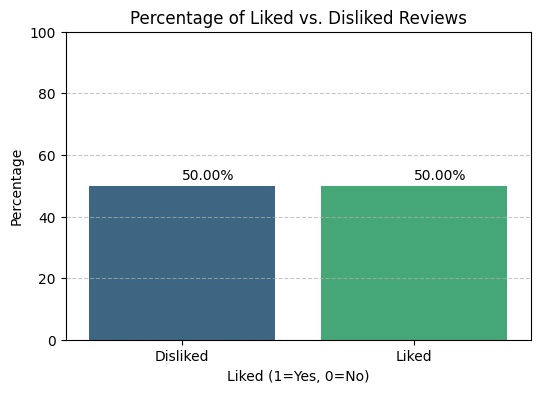

In [7]:
# Add code here 🔧
import matplotlib.pyplot as plt
import seaborn as sns

# Verify that rows were imported correctly
num_rows = df.shape[0]
print(f"Total number of reviews imported: {num_rows}")

# Calculate percentage of reviews that liked the restaurant
like_counts = df['Liked'].value_counts(normalize=True) * 100
print("\nPercentage of reviews:")
print(like_counts)

# Create bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x=like_counts.index, y=like_counts.values, palette='viridis')
plt.title('Percentage of Liked vs. Disliked Reviews')
plt.xlabel('Liked (1=Yes, 0=No)')
plt.ylabel('Percentage')
plt.xticks(ticks=[0, 1], labels=['Disliked', 'Liked'])
plt.ylim(0, 100)

for index, value in enumerate(like_counts.values):
    plt.text(index, value + 2, f'{value:.2f}%')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

### In Your Response:
1. What risks might occur if you included the review "junk" in your model?


In [10]:
# Add code here 🔧
import re

# Change reviews to lowercase letters
def preprocess_text(text):
    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs (a common pattern for URLs)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove anything that isn't a regular character
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['Review_Cleaned'] = df['Review'].apply(preprocess_text)
display(df[['Review', 'Review_Cleaned']].head())

,Review,Review_Cleaned
0,Wow... Loved this place.,wow loved this place
1,Crust is not good.,crust is not good
2,Not tasty and the texture was just nasty.,not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,stopped by during the late may bank holiday of...
4,The selection on the menu was great and so wer...,the selection on the menu was great and so wer...


### ✍️ Your Response: 🔧
1. Increased noise, reduced accuracy, higher dimensionality, and misinterpretation could all be included if "junk" were to be included.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%

### In Your Response:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)


In [11]:
# Add code here 🔧
# Install vaderSentiment library if not already installed
!pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment score
def get_sentiment(text):
    vs = analyzer.polarity_scores(text)
    if vs['compound'] >= 0.05:
        return 'Positive'
    elif vs['compound'] <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis
df['Sentiment'] = df['Review_Cleaned'].apply(get_sentiment)

# Calculate percentages of reviews
sentiment_counts = df['Sentiment'].value_counts(normalize=True) * 100
print("\nPercentage of reviews by Sentiment:")
print(sentiment_counts)

# Show
display(df[['Review', 'Review_Cleaned', 'Sentiment', 'Liked']].head())


Percentage of reviews by Sentiment:
Sentiment
Positive    50.6
Negative    25.5
Neutral     23.9
Name: proportion, dtype: float64


,Review,Review_Cleaned,Sentiment,Liked
0,Wow... Loved this place.,wow loved this place,Positive,1
1,Crust is not good.,crust is not good,Negative,0
2,Not tasty and the texture was just nasty.,not tasty and the texture was just nasty,Negative,0
3,Stopped by during the late May bank holiday of...,stopped by during the late may bank holiday of...,Positive,1
4,The selection on the menu was great and so wer...,the selection on the menu was great and so wer...,Positive,1


### ✍️ Your Response: 🔧
1. The liked column showed an even 50-50 split. Negative showed 25.5% and neutral showed 23.9%. This indicates that while 50% of reviews explicitly stated they liked the restaurant, VADER found slightly more positive sentiment overall.

2. From a restaurant owner's perspective, negative reviews would be the most important to analyze. These reviews directly highlight areas of dissatisfaction that needs immediate attention and improvement. Addressing these can prevent future customer churn and improve overall reputation.
While positive reviews are great for morale and marketing, they are generally less critical for identifying areas for improvement compared to negative and neutral.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

### In Your Response:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?


In [13]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK corpora (if not already downloaded)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab') # Added as per error message

# Initialize lemmatizer and get English stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Function for tokenization, stopword removal, and lemmatization
def process_review_for_topic_modeling(text):
    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and perform lemmatization
    processed_tokens = []
    for word in tokens:
        if word.isalpha() and word not in stop_words: # Ensure it's an alphabet and not a stopword
            processed_tokens.append(lemmatizer.lemmatize(word))
    return processed_tokens

# Apply the preprocessing function to the cleaned reviews
df['Review_Processed'] = df['Review_Cleaned'].apply(process_review_for_topic_modeling)

# Display the first 10 processed reviews
print("First 10 processed reviews:")
for i, review in enumerate(df['Review_Processed'].head(10)):
    print(f"Review {i+1}: {review}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


First 10 processed reviews:
Review 1: ['wow', 'loved', 'place']
Review 2: ['crust', 'good']
Review 3: ['tasty', 'texture', 'nasty']
Review 4: ['stopped', 'late', 'may', 'bank', 'holiday', 'rick', 'steve', 'recommendation', 'loved']
Review 5: ['selection', 'menu', 'great', 'price']
Review 6: ['getting', 'angry', 'want', 'damn', 'pho']
Review 7: ['honeslty', 'didnt', 'taste', 'fresh']
Review 8: ['potato', 'like', 'rubber', 'could', 'tell', 'made', 'ahead', 'time', 'kept', 'warmer']
Review 9: ['fry', 'great']
Review 10: ['great', 'touch']


### ✍️ Your Response: 🔧
1.  **What is a corpora and how is it used for text analysis?**
    *   A **corpus (plural: corpora)** is a large, structured collection of texts (written or spoken) used for linguistic research and analysis. It serves as a representative sample of a language or a specific domain of language. In text analysis, corpora are used to train and evaluate natural language processing (NLP) models, identify patterns, understand word frequencies, contexts, and grammatical structures. For instance, stopwords lists and lemmatization dictionaries (like WordNet) are derived from or are themselves types of corpora.

2.  **What would be the tokens in the first review? "Wow... Loved this place."**
    *   After the initial cleaning (lowercase, remove punctuation, remove extra spaces), the review becomes "wow loved this place".
    *   **Tokens:** Applying tokenization, the tokens would be: `['wow', 'loved', 'this', 'place']`.
    *   If stopwords were removed (`'this'` is a stopword) and lemmatization applied (`'loved'` -> `'love'`), the tokens for topic modeling would be: `['wow', 'love', 'place']`.

3.  **What does lemmatization do? How will it help in this process?**
    *   **Lemmatization** is the process of reducing inflected forms of a word to its base or dictionary form, known as the lemma. Unlike stemming, which simply chops off prefixes or suffixes (sometimes resulting in non-words), lemmatization uses vocabulary and morphological analysis of words to return the root form. For example, 'running', 'ran', and 'runs' would all be lemmatized to 'run'.
    *   **How it helps:** In topic analysis, lemmatization helps reduce the dimensionality of the data by treating different grammatical forms of the same word as a single term. This prevents words like 'eat', 'eating', and 'eats' from being counted as separate features, thereby making topic models more effective at identifying core themes by grouping related words. It improves the accuracy and interpretability of the topics by ensuring that words contributing to a single concept are represented cohesively.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

### In Your Response:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

In [15]:
!pip install gensim
from gensim.corpora.dictionary import Dictionary
from gensim.models.ldamodel import LdaModel

# Create a dictionary from the processed reviews
dictionary = Dictionary(df['Review_Processed'])

# Filter out words that appear in less than 5 documents or more than 50% of documents
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Create a Bag-of-Words corpus
corpus = [dictionary.doc2bow(text) for text in df['Review_Processed']]

# Display a summary of the dictionary and corpus
print("Dictionary summary:")
print(f"Number of unique tokens: {len(dictionary)}")
print("Sample word from dictionary:")
if len(dictionary) > 0:
    print(f"ID 0: {dictionary[0]}")

print("\nCorpus summary (first 5 documents):")
for i, doc in enumerate(corpus[:5]):
    print(f"Document {i+1}: {doc}")

# Respond to the markdown questions
# The markdown cell will be updated with the answers separately.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.7 MB/s eta 0:00:00
Dictionary summary:
Number of unique tokens: 256
Sample word from dictionary:
ID 0: loved

Corpus summary (first 5 documents):
Document 1: [(0, 1), (1, 1)]
Document 2: [(2, 1)]
Document 3: [(3, 1)]
Document 4: [(0, 1), (4, 1)]
Document 5: [(5, 1), (6, 1), (7, 1), (8, 1)]


### ✍️ Your Response: 🔧
1.  **What is a corpus and how is it useful?**
    *   In the context of topic modeling with Gensim, a **corpus** is a collection of documents represented in a structured, numerical format, typically as a Bag-of-Words (BoW) representation. Each document in the corpus is represented as a list of `(word_id, word_count)` tuples, where `word_id` refers to a unique integer assigned to each word in the dictionary, and `word_count` is the frequency of that word in the document.
    *   **How it is useful:** A corpus serves as the primary input for topic modeling algorithms like LDA. It transforms raw text into a format that machine learning models can understand and process efficiently. By converting documents into numerical vectors, it allows algorithms to identify patterns of word co-occurrence across documents, which are essential for discovering underlying topics.

2.  **How is a dictionary different from a corpus?**
    *   A **dictionary (or vocabulary)** is a mapping between words (tokens) and unique integer IDs. It essentially creates a numerical representation for every unique word encountered in the entire collection of documents. It does not contain any information about word frequencies within specific documents, only the mapping from word to ID and potentially overall frequencies or document frequencies.
    *   A **corpus**, on the other hand, is built *using* the dictionary. It represents each document as a sequence of `(word_id, word_count)` pairs. So, while the dictionary defines *what* words exist and their numerical identifiers, the corpus tells *which* words (by their IDs) appear in *each specific document* and *how many times* they appear. The dictionary is the key, and the corpus is the locked data that uses that key.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

### In Your Response:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


LDA Model Topics:
Topic 0: 0.038*"place" + 0.035*"amazing" + 0.028*"delicious" + 0.028*"pizza" + 0.028*"came" + 0.027*"nice" + 0.021*"salad" + 0.020*"wasnt" + 0.018*"taste" + 0.018*"good"
Topic 1: 0.075*"back" + 0.062*"good" + 0.042*"go" + 0.035*"best" + 0.028*"place" + 0.026*"ever" + 0.022*"star" + 0.020*"wont" + 0.019*"going" + 0.018*"also"
Topic 2: 0.127*"food" + 0.054*"service" + 0.053*"place" + 0.038*"great" + 0.031*"like" + 0.027*"would" + 0.026*"good" + 0.019*"never" + 0.019*"say" + 0.019*"really"
Topic 3: 0.073*"time" + 0.048*"great" + 0.022*"service" + 0.022*"place" + 0.021*"get" + 0.021*"table" + 0.020*"vega" + 0.020*"always" + 0.019*"think" + 0.018*"minute"
Topic 4: 0.031*"really" + 0.029*"chicken" + 0.026*"restaurant" + 0.024*"service" + 0.023*"flavor" + 0.023*"food" + 0.023*"disappointed" + 0.021*"enough" + 0.021*"bad" + 0.021*"good"

Dominant Topic for each Review (first 5 rows):


,Dominant_Topic,Perc_Contribution,Topic_Keywords,Text,Original_Review,Sentiment,Liked
0,3,0.7262,"time, great, service, place, get, table, vega,...",wow loved this place,Wow... Loved this place.,Positive,1
1,1,0.5963,"back, good, go, best, place, ever, star, wont,...",crust is not good,Crust is not good.,Negative,0
2,0,0.5983,"place, amazing, delicious, pizza, came, nice, ...",not tasty and the texture was just nasty,Not tasty and the texture was just nasty.,Negative,0
3,3,0.7328,"time, great, service, place, get, table, vega,...",stopped by during the late may bank holiday of...,Stopped by during the late May bank holiday of...,Positive,1
4,4,0.4413,"really, chicken, restaurant, service, flavor, ...",the selection on the menu was great and so wer...,The selection on the menu was great and so wer...,Positive,1



Frequency of Each Topic:
Dominant_Topic
0    21.5
1    22.9
2    23.1
3    16.4
4    16.1
Name: proportion, dtype: float64

Word Clouds for Each Topic:


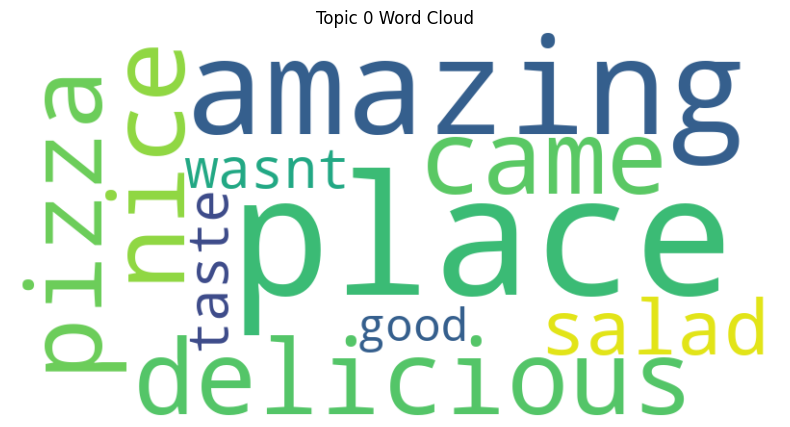

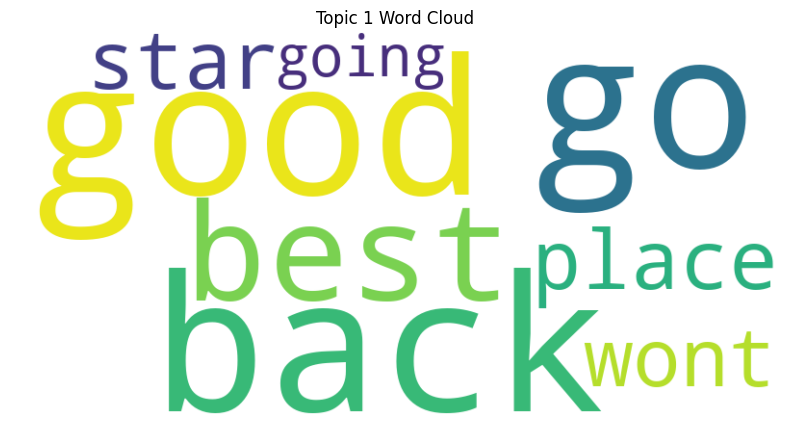

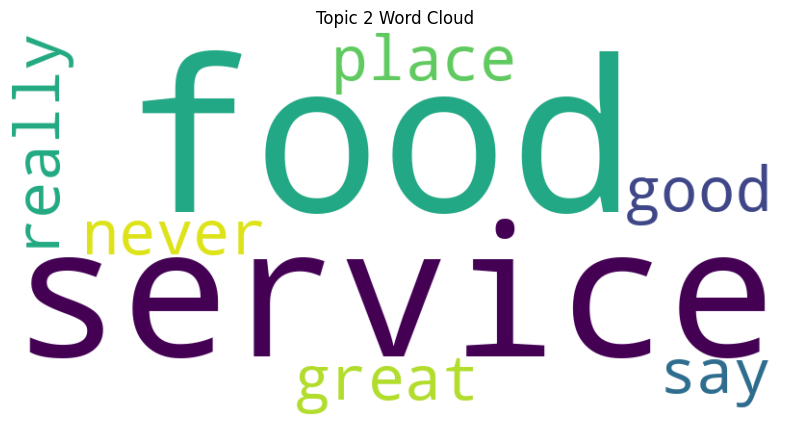

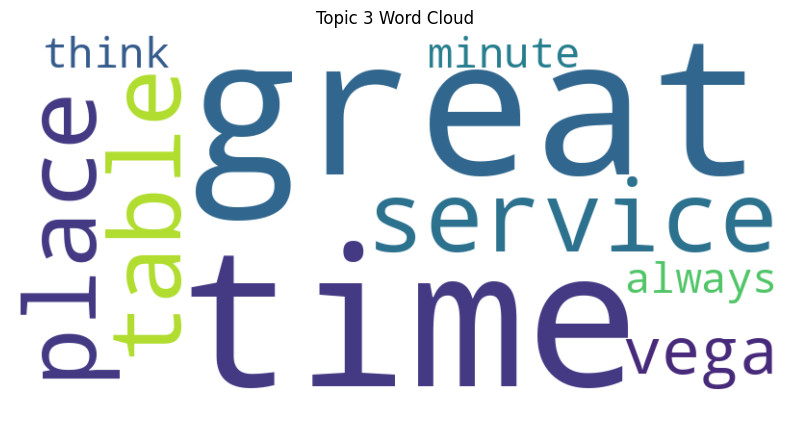

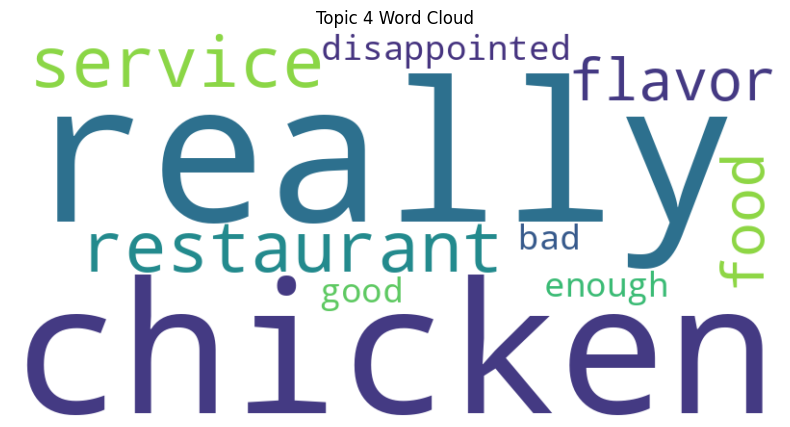


Sentiment Distribution by Topic (in %):


Sentiment,Negative,Neutral,Positive
Dominant_Topic,,,
0,23.255814,24.651163,52.093023
1,24.454148,25.764192,49.781659
2,25.974026,19.047619,54.978355
3,26.219512,31.097561,42.682927
4,28.571429,19.875776,51.552795


In [17]:
# Print the topics and top 10 words
print("LDA Model Topics:")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")

# Assign dominant topic to each review
def get_dominant_topic(ldamodel, corpus, texts):
    # Init output
    sent_topics_df = pd.DataFrame()

    # Get main topic in each document
    for i, corp in enumerate(corpus):
        topic_percs = ldamodel[corp]
        if not topic_percs:
            # Handle empty topic_percs for empty documents
            sent_topics_df = pd.concat([sent_topics_df, pd.DataFrame([{'Dominant_Topic': None, 'Perc_Contribution': None, 'Topic_Keywords': None, 'Text': texts[i]}])], ignore_index=True)
            continue

        dominant_topic = sorted(topic_percs, key=lambda x: x[1], reverse=True)[0][0]
        perc_contribution = sorted(topic_percs, key=lambda x: x[1], reverse=True)[0][1]
        topic_keywords = ldamodel.show_topic(dominant_topic)
        topic_keywords_str = ", ".join([word for word, prop in topic_keywords])
        sent_topics_df = pd.concat([sent_topics_df, pd.DataFrame([{'Dominant_Topic': int(dominant_topic), 'Perc_Contribution': round(perc_contribution, 4), 'Topic_Keywords': topic_keywords_str, 'Text': texts[i]}])], ignore_index=True)

    return sent_topics_df

df_topic_sents_keywords = get_dominant_topic(lda_model, corpus, df['Review_Cleaned'].tolist())

# Add the original 'Sentiment' and 'Liked' columns to this new dataframe
df_topic_sents_keywords['Original_Review'] = df['Review'].tolist()
df_topic_sents_keywords['Sentiment'] = df['Sentiment'].tolist()
df_topic_sents_keywords['Liked'] = df['Liked'].tolist()


# Display the first few rows of the dominant topic dataframe
print("\nDominant Topic for each Review (first 5 rows):")
display(df_topic_sents_keywords.head())

# Calculate topic frequencies
topic_counts = df_topic_sents_keywords['Dominant_Topic'].value_counts(normalize=True).sort_index() * 100
print("\nFrequency of Each Topic:")
print(topic_counts)

# --- Visual Display: Word Cloud for each Topic ---
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_wordcloud(topic_words, topic_id):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(topic_words)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Topic {topic_id} Word Cloud')
    plt.axis('off')
    plt.show()

print("\nWord Clouds for Each Topic:")
for i, topic_words in lda_model.show_topics(formatted=False):
    words = ' '.join([word for word, prop in topic_words])
    create_wordcloud(words, i)

# Summarize sentiment by topic
sentiment_by_topic = df_topic_sents_keywords.groupby('Dominant_Topic')['Sentiment'].value_counts(normalize=True).unstack().fillna(0) * 100

print("\nSentiment Distribution by Topic (in %):")
display(sentiment_by_topic)


In [16]:
from gensim.models.ldamodel import LdaModel

# Select the number of topics
num_topics = 5

# Build the LDA model
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=100)

# Print the topics to verify (optional, will be done in the next step more formally)
# print(lda_model.print_topics())

### ✍️ Your Response: 🔧
1.  **In what cases would you want to use more than 5 topics?**
    *   You might want to use more than 5 topics if the initial topics are too broad or generalized, and you suspect there are finer-grained discussions within the reviews that are being missed. For example, if a single topic lumps together 'food quality' and 'service speed', increasing the number of topics might separate these into distinct themes. More topics can also be useful when dealing with a very large and diverse dataset where a few topics wouldn't capture the full range of content.
    *   If you're looking for very specific insights or niche aspects mentioned in the reviews, a higher number of topics might be necessary to isolate those smaller themes.

2.  **How would you know if you have too many topics?**
    *   **Redundant or Overlapping Topics:** If multiple topics contain very similar sets of words, or if they seem to be discussing the same underlying theme, it suggests there are too many topics.
    *   **Incoherent or Uninterpretable Topics:** If the words within a topic don't seem to make logical sense together, or if you struggle to assign a meaningful label to a topic, it's a sign that the model might be over-segmenting the data.
    *   **Topics with Few Dominant Words:** If topics are not well-defined and consist of a wide array of less significant words, it could indicate too many topics.
    *   **Low Coherence Scores:** More advanced methods involve calculating topic coherence scores (e.g., using `CoherenceModel` from Gensim). A drop or stagnation in coherence scores as the number of topics increases can suggest that adding more topics is no longer improving the model's quality.
    *   **Practical Difficulty in Interpretation:** If you find it overwhelmingly difficult to interpret and act upon the insights from a large number of topics, then it's likely too many for practical use.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

### In Your Response:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"

LDA Model Topics:
Topic 0: 0.038*"place" + 0.035*"amazing" + 0.028*"delicious" + 0.028*"pizza" + 0.028*"came" + 0.027*"nice" + 0.021*"salad" + 0.020*"wasnt" + 0.018*"taste" + 0.018*"good"
Topic 1: 0.075*"back" + 0.062*"good" + 0.042*"go" + 0.035*"best" + 0.028*"place" + 0.026*"ever" + 0.022*"star" + 0.020*"wont" + 0.019*"going" + 0.018*"also"
Topic 2: 0.127*"food" + 0.054*"service" + 0.053*"place" + 0.038*"great" + 0.031*"like" + 0.027*"would" + 0.026*"good" + 0.019*"never" + 0.019*"say" + 0.019*"really"
Topic 3: 0.073*"time" + 0.048*"great" + 0.022*"service" + 0.022*"place" + 0.021*"get" + 0.021*"table" + 0.020*"vega" + 0.020*"always" + 0.019*"think" + 0.018*"minute"
Topic 4: 0.031*"really" + 0.029*"chicken" + 0.026*"restaurant" + 0.024*"service" + 0.023*"flavor" + 0.023*"food" + 0.023*"disappointed" + 0.021*"enough" + 0.021*"bad" + 0.021*"good"

Dominant Topic for each Review (first 5 rows):


,Dominant_Topic,Perc_Contribution,Topic_Keywords,Text,Original_Review,Sentiment,Liked
0,3,0.7263,"time, great, service, place, get, table, vega,...",wow loved this place,Wow... Loved this place.,Positive,1
1,1,0.5964,"back, good, go, best, place, ever, star, wont,...",crust is not good,Crust is not good.,Negative,0
2,0,0.5983,"place, amazing, delicious, pizza, came, nice, ...",not tasty and the texture was just nasty,Not tasty and the texture was just nasty.,Negative,0
3,3,0.7328,"time, great, service, place, get, table, vega,...",stopped by during the late may bank holiday of...,Stopped by during the late May bank holiday of...,Positive,1
4,4,0.4413,"really, chicken, restaurant, service, flavor, ...",the selection on the menu was great and so wer...,The selection on the menu was great and so wer...,Positive,1



Frequency of Each Topic:
Dominant_Topic
0    21.5
1    23.0
2    23.0
3    16.4
4    16.1
Name: proportion, dtype: float64

Word Clouds for Each Topic:


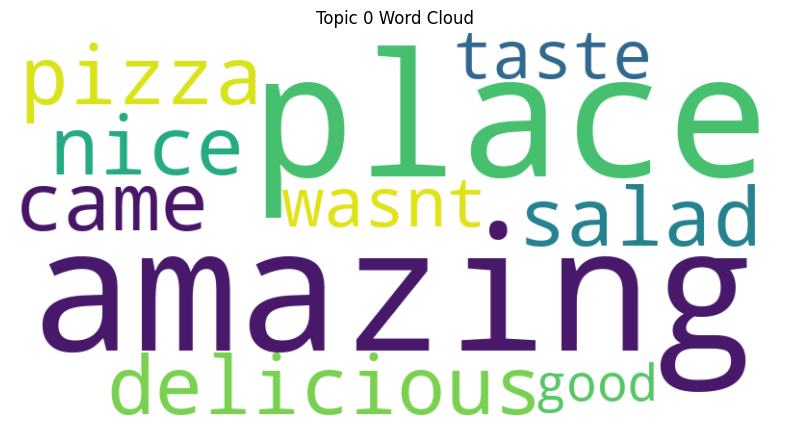

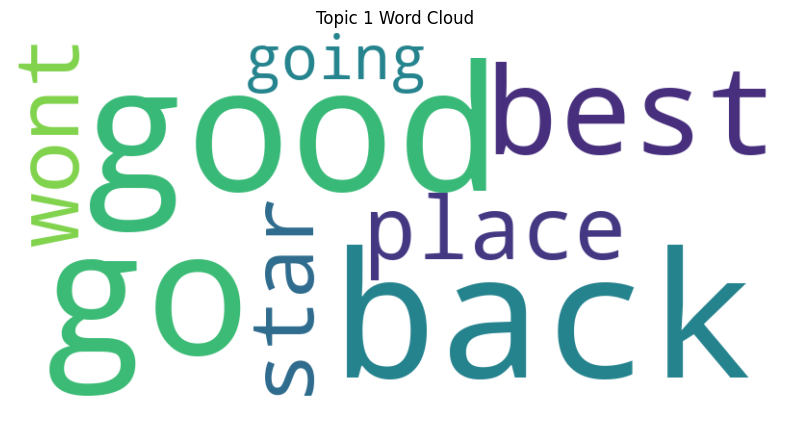

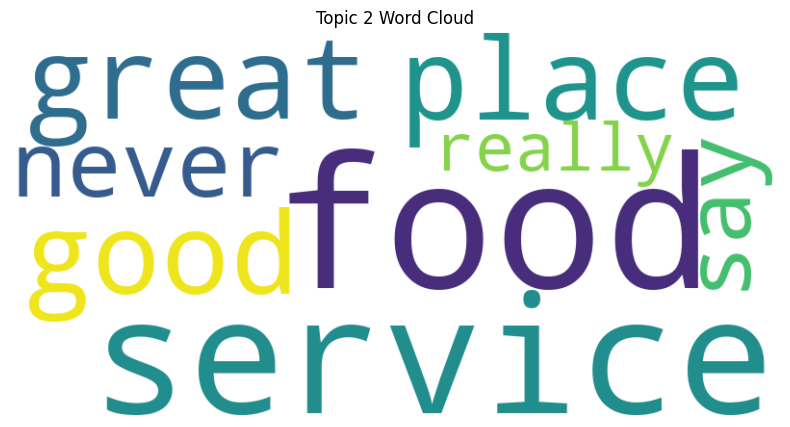

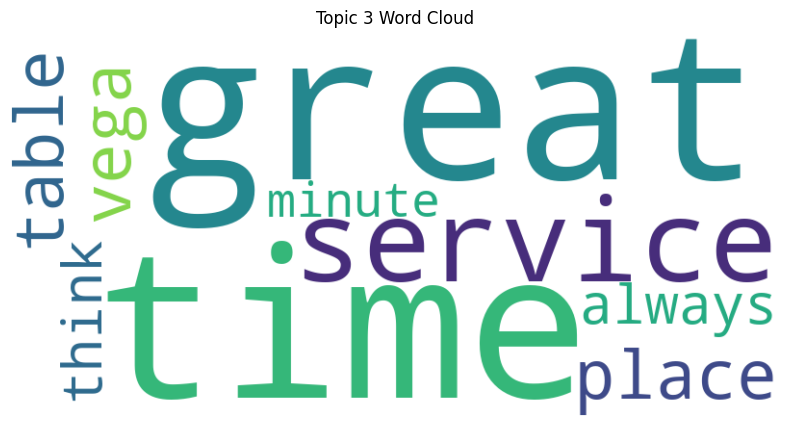

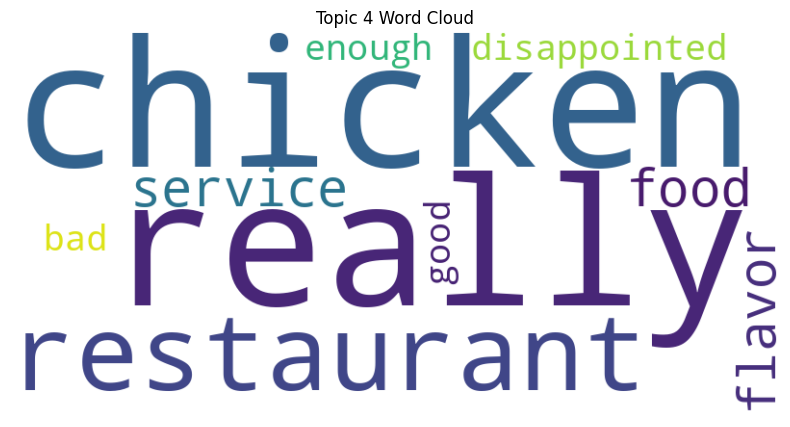


Sentiment Distribution by Topic (in %):


Sentiment,Negative,Neutral,Positive
Dominant_Topic,,,
0,23.255814,24.651163,52.093023
1,24.347826,26.086957,49.565217
2,26.086957,18.695652,55.217391
3,26.219512,31.097561,42.682927
4,28.571429,19.875776,51.552795


In [18]:
# Add code here 🔧
# Print the topics and top 10 words
print("LDA Model Topics:")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")

# Assign dominant topic to each review
def get_dominant_topic(ldamodel, corpus, texts):
    # Init output
    sent_topics_df = pd.DataFrame()

    # Get main topic in each document
    for i, corp in enumerate(corpus):
        topic_percs = ldamodel[corp]
        if not topic_percs:
            # Handle empty topic_percs for empty documents
            sent_topics_df = pd.concat([sent_topics_df, pd.DataFrame([{'Dominant_Topic': None, 'Perc_Contribution': None, 'Topic_Keywords': None, 'Text': texts[i]}])], ignore_index=True)
            continue

        dominant_topic = sorted(topic_percs, key=lambda x: x[1], reverse=True)[0][0]
        perc_contribution = sorted(topic_percs, key=lambda x: x[1], reverse=True)[0][1]
        topic_keywords = ldamodel.show_topic(dominant_topic)
        topic_keywords_str = ", ".join([word for word, prop in topic_keywords])
        sent_topics_df = pd.concat([sent_topics_df, pd.DataFrame([{'Dominant_Topic': int(dominant_topic), 'Perc_Contribution': round(perc_contribution, 4), 'Topic_Keywords': topic_keywords_str, 'Text': texts[i]}])], ignore_index=True)

    return sent_topics_df

df_topic_sents_keywords = get_dominant_topic(lda_model, corpus, df['Review_Cleaned'].tolist())

# Add the original 'Sentiment' and 'Liked' columns to this new dataframe
df_topic_sents_keywords['Original_Review'] = df['Review'].tolist()
df_topic_sents_keywords['Sentiment'] = df['Sentiment'].tolist()
df_topic_sents_keywords['Liked'] = df['Liked'].tolist()


# Display the first few rows of the dominant topic dataframe
print("\nDominant Topic for each Review (first 5 rows):")
display(df_topic_sents_keywords.head())

# Calculate topic frequencies
topic_counts = df_topic_sents_keywords['Dominant_Topic'].value_counts(normalize=True).sort_index() * 100
print("\nFrequency of Each Topic:")
print(topic_counts)

# --- Visual Display: Word Cloud for each Topic ---
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_wordcloud(topic_words, topic_id):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(topic_words)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Topic {topic_id} Word Cloud')
    plt.axis('off')
    plt.show()

print("\nWord Clouds for Each Topic:")
for i, topic_words in lda_model.show_topics(formatted=False):
    words = ' '.join([word for word, prop in topic_words])
    create_wordcloud(words, i)

# Summarize sentiment by topic
sentiment_by_topic = df_topic_sents_keywords.groupby('Dominant_Topic')['Sentiment'].value_counts(normalize=True).unstack().fillna(0) * 100

print("\nSentiment Distribution by Topic (in %):")
display(sentiment_by_topic)

### ✍️ Your Response: 🔧
List your topics and names here:

Topic 0: Food & Atmosphere
Topic 1: Return Visits
Topic 2: Overall Experience
Topic 3: Service & Timing
Topic 4: Food Satisfaction

## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


### ✍️ Your Response: 🔧
1.  **What business question did your model help answer?**
    *   The model helped answer: "What are the main themes and sentiments expressed by customers in their reviews, and how do these relate to overall satisfaction (Liked/Disliked)?"
    *   Specifically, it broke down customer feedback into actionable topics and revealed the sentiment distribution within each, allowing the restaurant to understand *what* aspects drive positive or negative experiences beyond a simple 'like' or 'dislike'.

2.  **What would you recommend to this restaurant to improve customer satisfaction?**
    *   **Focus on Service & Timing (Topic 3):** This topic, despite having relatively high positive sentiment, also shows a significant neutral percentage and is directly related to operational aspects like `time`, `service`, `table`, and `minute`. The restaurant should monitor wait times, staff efficiency, and table readiness to ensure a smooth dining experience. Speeding up service without compromising quality could convert neutral experiences into positive ones.
    *   **Address Negative 'Food & Atmosphere' Feedback (Topic 0) and 'Food Satisfaction' (Topic 4):** While these topics generally have high positive sentiment, the presence of words like `wasnt`, `bad`, `disappointed`, `chicken`, `flavor` suggests specific areas for improvement. The restaurant should investigate specific dishes or aspects of the ambiance that are leading to negative reviews within these topics. For example, if 'pizza' or 'salad' are consistently associated with negative feedback in Topic 0, these menu items need re-evaluation. Similarly, issues with `chicken` or `flavor` in Topic 4 should be prioritized.
    *   **Leverage 'Return Visits' (Topic 1) Insights:** This topic includes `back`, `best`, `ever`, `star`, suggesting strong customer loyalty. The restaurant should identify what specifically makes these customers want to return (e.g., consistency, specific dishes, atmosphere) and reinforce those strengths through marketing and staff training.

3.  **What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?**
    *   **Pros:**
        *   **Ease of Use & Speed:** LLMs can process and summarize text quickly, often with a single prompt, requiring less coding knowledge.
        *   **Contextual Understanding:** They can infer nuance, sarcasm, and complex contexts that rule-based or simpler statistical models might miss.
        *   **Human-like Interpretation:** LLMs can provide natural language explanations and summaries of topics and sentiments that are immediately understandable.
        *   **No Library Dependencies:** No need to install and manage various NLP libraries (NLTK, Gensim).
    *   **Cons:**
        *   **Lack of Control & Reproducibility:** The exact methodology and decision-making process of an LLM are often opaque, making it hard to control, fine-tune, or reproduce results consistently.
        *   **Cost & Privacy:** API usage can incur costs, and sending sensitive review data to third-party LLMs might raise privacy concerns.
        *   **Hallucination/Bias:** LLMs can sometimes generate plausible but incorrect or biased interpretations.
        *   **Scalability for Large Datasets:** Processing extremely large datasets might be slower or more expensive with LLMs compared to optimized Python libraries.
        *   **Specific Customization:** Achieving very specific, domain-tailored analyses or integrating with other data pipelines can be more challenging.

4.  **If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment? (remember to set the context, specify the output and explain the objectives)**

    ```
    You are an expert text analyst specializing in restaurant customer feedback. Your task is to analyze a dataset of restaurant reviews, identify key themes, determine the sentiment of each review, and provide actionable business insights.

    **Input Data:** I will provide a CSV-like text where each line represents a review, followed by a 'Liked' indicator (1 for liked, 0 for disliked). Each review needs to be analyzed independently.

    **Objectives:**
    1.  **Text Preprocessing:** Clean each review by converting to lowercase, removing URLs, punctuation, and extra spaces. Only focus on alphanumeric characters.
    2.  **Sentiment Analysis:** For each cleaned review, classify its sentiment as 'Positive', 'Negative', or 'Neutral'.
    3.  **Topic Modeling:** Identify 5 distinct topics discussed across all reviews. For each topic, list the top 10 most representative words and provide a concise 2-3 word summary name.
    4.  **Summary Statistics:** Calculate the overall percentage of 'Positive', 'Negative', and 'Neutral' sentiments. Also, calculate the frequency (percentage of reviews belonging to) for each identified topic.
    5.  **Actionable Recommendations:** Based on the identified topics and their associated sentiments, provide 3-5 specific recommendations for the restaurant owner to improve customer satisfaction and business operations. Prioritize recommendations that address negative feedback within prevalent topics.

    **Output Format:** Present your analysis in a structured markdown format, including:
    *   A section for Overall Sentiment Distribution.
    *   A section for Identified Topics, each with its summary name, top words, and frequency.
    *   A table showing Sentiment Distribution by Topic (percentage of Positive/Neutral/Negative reviews within each topic).
    *   A final section for Actionable Business Recommendations.

    **Example Input:**
    Review,Liked
    "Wow... Loved this place.",1
    "Crust is not good.",0
    "Stopped by during the late May bank holiday of 2024. Rick Steves' recommendation. Loved it!",1
    "The selection on the menu was great and so were the prices!",1
    "Getting angry now! I want my damn pho!",0
    
    **Start your analysis now.**
    ```

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_13_ThorntonJackson.ipynb"